In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

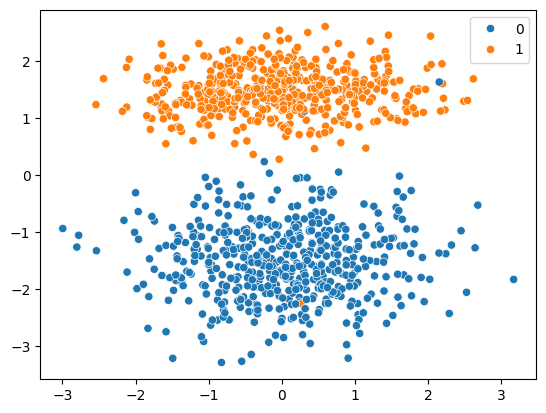

In [63]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=1.5, random_state=0)
sns.scatterplot(x=X[:, 0], y = X[:, 1], hue=y)
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((700, 2), (300, 2), (700,), (300,))

In [ ]:
def step(i:float) -> int:
    return 1 if i>=0 else 0

In [50]:
class Logistic_Regression_using_Perceptron:

    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = step(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

In [68]:
clf = Logistic_Regression_using_Perceptron(1000, 0.01)

clf.fit(X_train, y_train)

print(f"Coefficient : {clf.coef_} || Intercept : {clf.intercept_}")

print(accuracy_score(y_test, clf.predict(X_test)))

Coefficient : [0.38289166 1.33165373] || Intercept : 0.3299999999999994
0.9733333333333334


In [52]:
org_log = LogisticRegression()

org_log.fit(X_train, y_train)

print(f"Coefficient : {org_log.coef_} || Intercept : {org_log.intercept_}")

print(accuracy_score(y_test, org_log.predict(X_test)))

Coefficient : [[-0.19893151  4.22463957]] || Intercept : [-0.80609297]
0.9933333333333333


<h4>See there is a major difference in the fitting because Sklearn's LogiisticRegression uses the Sigmoid Function and we used Perceptron Trick</h4>

#### Now let's see the line that both classifier predicted

In [69]:
m = -(clf.coef_[0] / clf.coef_[1])
b = -(clf.intercept_ / clf.coef_[1])

m_org = -(org_log.coef_[0, 0] / org_log.coef_[0, 1])
b_org = -(org_log.intercept_ / org_log.coef_[0, 1])

#### These are the slopes and bias of the model's predicted lines

In [70]:
x = np.linspace(-3.5, 3.5, 100)
y_perceptron = m*x + b

y_org = m_org * x + b_org

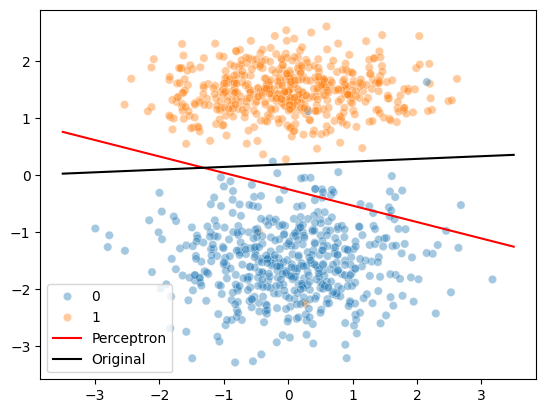

In [76]:
sns.scatterplot(x=X[:, 0], y = X[:, 1], hue=y, alpha = 0.4)
sns.lineplot(x = x, y = y_perceptron, label = "Perceptron", color = 'red')
sns.lineplot(x = x, y = y_org, label = "Original", color = 'Black')
plt.legend()
plt.show()

#### As we can see even after 1000 iteration it has lower score than sklearn's LogisticRegression

### Now let's see how this line shifts through animation

In [85]:
def perceptron(X, y):
    m = []
    b = []

    X = np.insert(X, 0, 1, axis = 1)
    w = np.ones(X.shape[1])

    lr = 0.01

    for i in range(1000):
        idx = np.random.randint(0, X.shape[0])
        y_pred = step(np.dot(X[idx], w))
        w += lr * (y[idx] - y_pred) * X[idx]

        m.append(-(w[1] / w[2]))
        b.append(-(w[0] / w[2]))
    
    return m, b

In [86]:
m, b= perceptron(X, y)

In [84]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [87]:
fig, ax = plt.subplots(figsize = (9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i* m[0] + b[0]

ax.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
line = ax.plot(x_i, y_i, 'r-', linewidth = 2)
plt.ylim(-3, 3)

def update(i):
    label = f"epoch {i+1}"
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_label(label)
animation = FuncAnimation(fig, update, repeat = True, frames=1000, interval = 100)

<IPython.core.display.Javascript object>